# Assignment 02 — SQL Sales Analysis: Sample Superstore

**Objective:** Analyze sales data using SQL with filtering, aggregation, and business queries.


## Steps to do/ Workflow 
1. Load dataset into a SQL database
2. Explore table schema and sample data
3. Apply `WHERE` filters (region, category, date, sales)
4. Use `GROUP BY` for aggregations
5. Sort and limit results (top products, top categories)
6. Solve business use cases (monthly trends, top customers, duplicates)
7. Validate results (row counts, data quality)

## Setup & Imports

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Display helpers ──────────────────────────────────────────────────────────
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)

plt.rcParams.update({
    'figure.facecolor': '#f9f9f9',
    'axes.facecolor':   '#f9f9f9',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size': 11,
})

DATASET_PATH = r'C:\Users\Asus\OneDrive\Celebal tech\Assignment02\dataset\Sample - Superstore.csv'
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Step 1 — Load Dataset into SQLite Database

In [2]:
# ── 1. Read CSV ───────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATASET_PATH, encoding='latin1')

# ── 2. Clean column names (SQL-friendly: spaces → underscores, remove hyphens)
df_raw.columns = (
    df_raw.columns
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('-', '_')
    .str.lower()
)

# ── 3. Parse dates
df_raw['order_date'] = pd.to_datetime(df_raw['order_date'], format='%m/%d/%Y')
df_raw['ship_date']  = pd.to_datetime(df_raw['ship_date'],  format='%m/%d/%Y')

# ── 4. Create in-memory SQLite DB and load table
conn = sqlite3.connect(':memory:')
df_raw.to_sql('superstore', conn, index=False, if_exists='replace')

print(f'Table loaded: {len(df_raw):,} rows, {len(df_raw.columns)} columns')
print('Columns:', df_raw.columns.tolist())

Table loaded: 9,994 rows, 21 columns
Columns: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [3]:
# ── Reusable helper: run SQL and return a styled DataFrame ────────────────────
def sql(query, title=None):
    result = pd.read_sql_query(query, conn)
    if title:
        print(f'\n── {title} ──')
    return result

print('Helper function `sql()` registered.')

Helper function `sql()` registered.


---
## Step 2 — Explore Table (Schema & Sample Data)

In [4]:
# ── 2a. Schema via PRAGMA ─────────────────────────────────────────────────────
schema = sql("""
    PRAGMA table_info(superstore);
""", title='Table Schema')

schema[['name', 'type']].rename(columns={'name': 'Column', 'type': 'Data Type'})


── Table Schema ──


,Column,Data Type
0,row_id,INTEGER
1,order_id,TEXT
2,order_date,TIMESTAMP
3,ship_date,TIMESTAMP
4,ship_mode,TEXT
5,customer_id,TEXT
6,customer_name,TEXT
7,segment,TEXT
8,country,TEXT
9,city,TEXT


In [5]:
# ── 2b. Sample rows ───────────────────────────────────────────────────────────
sql("""
    SELECT
        order_id,
        order_date,
        customer_name,
        region,
        category,
        sub_category,
        sales,
        quantity,
        discount,
        profit
    FROM superstore
    LIMIT 10;
""", title='First 10 Rows')


── First 10 Rows ──


,order_id,order_date,customer_name,region,category,sub_category,sales,quantity,discount,profit
0,CA-2016-152156,2016-11-08 00:00:00,Claire Gute,South,Furniture,Bookcases,261.96,2,0.00,41.91
1,CA-2016-152156,2016-11-08 00:00:00,Claire Gute,South,Furniture,Chairs,731.94,3,0.00,219.58
2,CA-2016-138688,2016-06-12 00:00:00,Darrin Van Huff,West,Office Supplies,Labels,14.62,2,0.00,6.87
3,US-2015-108966,2015-10-11 00:00:00,Sean O'Donnell,South,Furniture,Tables,957.58,5,0.45,-383.03
4,US-2015-108966,2015-10-11 00:00:00,Sean O'Donnell,South,Office Supplies,Storage,22.37,2,0.20,2.52
5,CA-2014-115812,2014-06-09 00:00:00,Brosina Hoffman,West,Furniture,Furnishings,48.86,7,0.00,14.17
6,CA-2014-115812,2014-06-09 00:00:00,Brosina Hoffman,West,Office Supplies,Art,7.28,4,0.00,1.97
7,CA-2014-115812,2014-06-09 00:00:00,Brosina Hoffman,West,Technology,Phones,907.15,6,0.20,90.72
8,CA-2014-115812,2014-06-09 00:00:00,Brosina Hoffman,West,Office Supplies,Binders,18.50,3,0.20,5.78
9,CA-2014-115812,2014-06-09 00:00:00,Brosina Hoffman,West,Office Supplies,Appliances,114.90,5,0.00,34.47


In [6]:
# ── 2c. Table summary statistics ──────────────────────────────────────────────
sql("""
    SELECT
        COUNT(*)                        AS total_rows,
        COUNT(DISTINCT order_id)        AS unique_orders,
        COUNT(DISTINCT customer_id)     AS unique_customers,
        COUNT(DISTINCT product_id)      AS unique_products,
        COUNT(DISTINCT region)          AS regions,
        COUNT(DISTINCT category)        AS categories,
        COUNT(DISTINCT state)           AS states,
        ROUND(MIN(sales), 2)            AS min_sales,
        ROUND(MAX(sales), 2)            AS max_sales,
        ROUND(SUM(sales), 2)            AS total_sales,
        ROUND(SUM(profit), 2)           AS total_profit
    FROM superstore;
""", title='Summary Statistics')


── Summary Statistics ──


,total_rows,unique_orders,unique_customers,unique_products,regions,categories,states,min_sales,max_sales,total_sales,total_profit
0,9994,5009,793,1862,4,3,49,0.44,"22,638.48","2,297,200.86","286,397.02"


In [7]:
# ── 2d. Distinct values in key categorical columns ────────────────────────────
for col, q in [
    ('Regions',    'SELECT DISTINCT region   AS value FROM superstore ORDER BY 1'),
    ('Categories', 'SELECT DISTINCT category AS value FROM superstore ORDER BY 1'),
    ('Segments',   'SELECT DISTINCT segment  AS value FROM superstore ORDER BY 1'),
    ('Ship Modes', 'SELECT DISTINCT ship_mode AS value FROM superstore ORDER BY 1'),
]:
    vals = pd.read_sql_query(q, conn)['value'].tolist()
    print(f'{col:12}: {vals}')

Regions     : ['Central', 'East', 'South', 'West']
Categories  : ['Furniture', 'Office Supplies', 'Technology']
Segments    : ['Consumer', 'Corporate', 'Home Office']
Ship Modes  : ['First Class', 'Same Day', 'Second Class', 'Standard Class']


---
## Step 3 — WHERE Filters

In [8]:
# ── 3a. Filter by Region: West ────────────────────────────────────────────────
sql("""
    SELECT
        order_id,
        order_date,
        customer_name,
        state,
        category,
        ROUND(sales, 2) AS sales,
        ROUND(profit, 2) AS profit
    FROM superstore
    WHERE region = 'West'
    LIMIT 10;
""", title='Filter: Region = West (sample 10)')


── Filter: Region = West (sample 10) ──


,order_id,order_date,customer_name,state,category,sales,profit
0,CA-2016-138688,2016-06-12 00:00:00,Darrin Van Huff,California,Office Supplies,14.62,6.87
1,CA-2014-115812,2014-06-09 00:00:00,Brosina Hoffman,California,Furniture,48.86,14.17
2,CA-2014-115812,2014-06-09 00:00:00,Brosina Hoffman,California,Office Supplies,7.28,1.97
3,CA-2014-115812,2014-06-09 00:00:00,Brosina Hoffman,California,Technology,907.15,90.72
4,CA-2014-115812,2014-06-09 00:00:00,Brosina Hoffman,California,Office Supplies,18.50,5.78
5,CA-2014-115812,2014-06-09 00:00:00,Brosina Hoffman,California,Office Supplies,114.90,34.47
6,CA-2014-115812,2014-06-09 00:00:00,Brosina Hoffman,California,Furniture,"1,706.18",85.31
7,CA-2014-115812,2014-06-09 00:00:00,Brosina Hoffman,California,Technology,911.42,68.36
8,CA-2016-161389,2016-12-05 00:00:00,Irene Maddox,Washington,Office Supplies,407.98,132.59
9,CA-2014-167164,2014-05-13 00:00:00,Alejandro Grove,Utah,Office Supplies,55.50,9.99


In [9]:
# ── 3b. Filter by Category: Technology ───────────────────────────────────────
sql("""
    SELECT
        order_id,
        order_date,
        customer_name,
        sub_category,
        product_name,
        ROUND(sales, 2)    AS sales,
        ROUND(profit, 2)   AS profit
    FROM superstore
    WHERE category = 'Technology'
    ORDER BY sales DESC
    LIMIT 10;
""", title='Filter: Category = Technology, Top 10 by Sales')


── Filter: Category = Technology, Top 10 by Sales ──


,order_id,order_date,customer_name,sub_category,product_name,sales,profit
0,CA-2014-145317,2014-03-18 00:00:00,Sean Miller,Machines,Cisco TelePresence System EX90 Videoconferenci...,"22,638.48","-1,811.08"
1,CA-2016-118689,2016-10-02 00:00:00,Tamara Chand,Copiers,Canon imageCLASS 2200 Advanced Copier,"17,499.95","8,399.98"
2,CA-2017-140151,2017-03-23 00:00:00,Raymond Buch,Copiers,Canon imageCLASS 2200 Advanced Copier,"13,999.96","6,719.98"
3,CA-2017-127180,2017-10-22 00:00:00,Tom Ashbrook,Copiers,Canon imageCLASS 2200 Advanced Copier,"11,199.97","3,919.99"
4,CA-2017-166709,2017-11-17 00:00:00,Hunter Lopez,Copiers,Canon imageCLASS 2200 Advanced Copier,"10,499.97","5,039.99"
5,US-2016-107440,2016-04-16 00:00:00,Bill Shonely,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta","9,099.93","2,365.98"
6,CA-2016-158841,2016-02-02 00:00:00,Sanjit Engle,Machines,HP Designjet T520 Inkjet Large Format Printer ...,"8,749.95","2,799.98"
7,CA-2016-143714,2016-05-23 00:00:00,Christopher Conant,Copiers,Canon imageCLASS 2200 Advanced Copier,"8,399.98","1,120.00"
8,CA-2014-139892,2014-09-08 00:00:00,Becky Martin,Machines,Lexmark MX611dhe Monochrome Laser Printer,"8,159.95","-1,359.99"
9,US-2017-168116,2017-11-04 00:00:00,Grant Thornton,Machines,Cubify CubeX 3D Printer Triple Head Print,"7,999.98","-3,839.99"


In [10]:
# ── 3c. Filter by Date Range: Year 2017 ──────────────────────────────────────
sql("""
    SELECT
        order_id,
        order_date,
        customer_name,
        region,
        category,
        ROUND(sales, 2)   AS sales
    FROM superstore
    WHERE order_date >= '2017-01-01'
      AND order_date <= '2017-12-31'
    ORDER BY order_date
    LIMIT 10;
""", title='Filter: Orders in Year 2017 (sample 10)')


── Filter: Orders in Year 2017 (sample 10) ──


,order_id,order_date,customer_name,region,category,sales
0,CA-2017-107503,2017-01-01 00:00:00,Guy Armstrong,East,Furniture,48.90
1,CA-2017-144463,2017-01-01 00:00:00,Steven Cartwright,West,Furniture,474.43
2,CA-2017-154466,2017-01-01 00:00:00,Dennis Pardue,Central,Office Supplies,3.60
3,CA-2017-151750,2017-01-01 00:00:00,Janet Martin,Central,Office Supplies,454.56
4,CA-2017-151750,2017-01-01 00:00:00,Janet Martin,Central,Furniture,141.42
5,CA-2017-151750,2017-01-01 00:00:00,Janet Martin,Central,Furniture,310.74
6,CA-2017-151750,2017-01-01 00:00:00,Janet Martin,Central,Office Supplies,12.74
7,CA-2017-151750,2017-01-01 00:00:00,Janet Martin,Central,Office Supplies,6.47
8,CA-2017-151750,2017-01-01 00:00:00,Janet Martin,Central,Office Supplies,13.75
9,CA-2017-151750,2017-01-01 00:00:00,Janet Martin,Central,Office Supplies,15.22


In [11]:
# ── Count of orders per year
sql("""
    SELECT
        strftime('%Y', order_date) AS year,
        COUNT(*)                   AS total_orders,
        ROUND(SUM(sales), 2)       AS total_sales
    FROM superstore
    GROUP BY year
    ORDER BY year;
""", title='Orders & Sales by Year')


── Orders & Sales by Year ──


,year,total_orders,total_sales
0,2014,1993,"484,247.50"
1,2015,2102,"470,532.51"
2,2016,2587,"609,205.60"
3,2017,3312,"733,215.26"


In [12]:
# ── 3d. Filter by Sales threshold: Sales > 1000 ───────────────────────────────
high_sales = sql("""
    SELECT
        order_id,
        customer_name,
        category,
        sub_category,
        product_name,
        ROUND(sales, 2)  AS sales,
        ROUND(profit, 2) AS profit
    FROM superstore
    WHERE sales > 1000
    ORDER BY sales DESC
    LIMIT 15;
""", title='Filter: Sales > $1,000 (Top 15)')
high_sales


── Filter: Sales > $1,000 (Top 15) ──


,order_id,customer_name,category,sub_category,product_name,sales,profit
0,CA-2014-145317,Sean Miller,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,"22,638.48","-1,811.08"
1,CA-2016-118689,Tamara Chand,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,"17,499.95","8,399.98"
2,CA-2017-140151,Raymond Buch,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,"13,999.96","6,719.98"
3,CA-2017-127180,Tom Ashbrook,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,"11,199.97","3,919.99"
4,CA-2017-166709,Hunter Lopez,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,"10,499.97","5,039.99"
5,CA-2016-117121,Adrian Barton,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,"9,892.74","4,946.37"
6,CA-2014-116904,Sanjit Chand,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,"9,449.95","4,630.48"
7,US-2016-107440,Bill Shonely,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta","9,099.93","2,365.98"
8,CA-2016-158841,Sanjit Engle,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,"8,749.95","2,799.98"
9,CA-2016-143714,Christopher Conant,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,"8,399.98","1,120.00"


In [13]:
# ── 3e. Combined filter: Technology in West with Discount > 0 ─────────────────
sql("""
    SELECT
        order_id,
        order_date,
        customer_name,
        sub_category,
        ROUND(sales, 2)    AS sales,
        ROUND(discount, 2) AS discount,
        ROUND(profit, 2)   AS profit
    FROM superstore
    WHERE region   = 'West'
      AND category = 'Technology'
      AND discount  > 0
    ORDER BY discount DESC
    LIMIT 10;
""", title='Combined Filter: West + Technology + Discount > 0')


── Combined Filter: West + Technology + Discount > 0 ──


,order_id,order_date,customer_name,sub_category,sales,discount,profit
0,US-2017-155425,2017-11-10 00:00:00,Ann Blume,Machines,95.99,0.70,-64.00
1,CA-2017-134845,2017-04-17 00:00:00,Sharelle Roach,Machines,"2,549.99",0.70,"-3,399.98"
2,US-2015-131359,2015-10-30 00:00:00,Frank Atkinson,Machines,59.99,0.70,-46.00
3,CA-2016-109827,2016-12-25 00:00:00,Laurel Workman,Machines,269.97,0.70,-386.96
4,CA-2017-159282,2017-10-16 00:00:00,Gary Hansen,Machines,599.99,0.70,-479.99
5,CA-2014-131947,2014-09-17 00:00:00,Joseph Airdo,Machines,29.93,0.70,-21.95
6,US-2016-157490,2016-10-06 00:00:00,Laurel Beltran,Machines,703.71,0.70,-938.28
7,CA-2016-159023,2016-11-03 00:00:00,Natalie Webber,Machines,179.99,0.70,-251.99
8,CA-2014-115812,2014-06-09 00:00:00,Brosina Hoffman,Phones,907.15,0.20,90.72
9,CA-2014-115812,2014-06-09 00:00:00,Brosina Hoffman,Phones,911.42,0.20,68.36


---
## Step 4 — GROUP BY Aggregations

In [14]:
# ── 4a. Total Sales, Profit & Orders by Region ────────────────────────────────
by_region = sql("""
    SELECT
        region,
        COUNT(*)                      AS total_orders,
        ROUND(SUM(sales), 2)          AS total_sales,
        ROUND(SUM(profit), 2)         AS total_profit,
        ROUND(AVG(sales), 2)          AS avg_order_sales,
        ROUND(SUM(profit)*100.0
              / SUM(sales), 2)        AS profit_margin_pct
    FROM superstore
    GROUP BY region
    ORDER BY total_sales DESC;
""", title='Sales & Profit by Region')
by_region


── Sales & Profit by Region ──


,region,total_orders,total_sales,total_profit,avg_order_sales,profit_margin_pct
0,West,3203,"725,457.82","108,418.45",226.49,14.94
1,East,2848,"678,781.24","91,522.78",238.34,13.48
2,Central,2323,"501,239.89","39,706.36",215.77,7.92
3,South,1620,"391,721.91","46,749.43",241.80,11.93


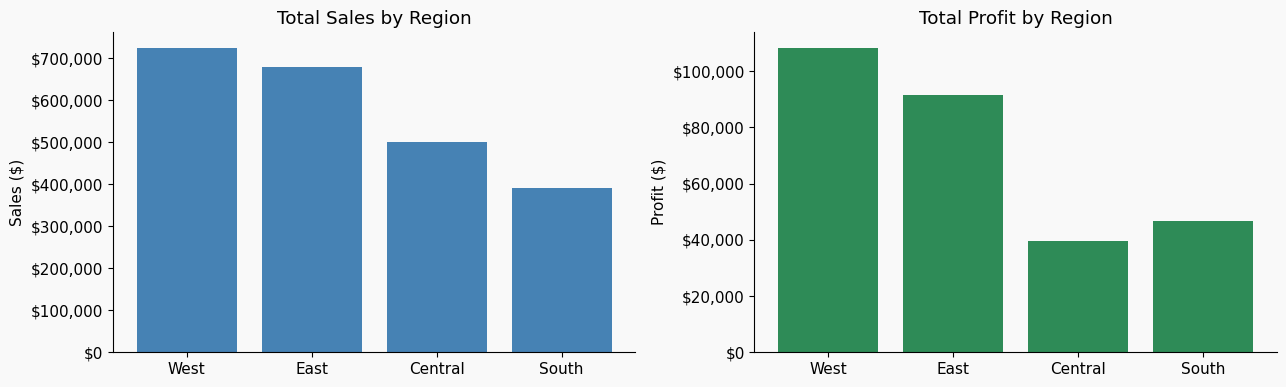

In [15]:
# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(by_region['region'], by_region['total_sales'], color='steelblue')
axes[0].set_title('Total Sales by Region')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].bar(by_region['region'], by_region['total_profit'], color='seagreen')
axes[1].set_title('Total Profit by Region')
axes[1].set_ylabel('Profit ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig(r'C:\Users\Asus\OneDrive\Celebal tech\Assignment02\sales_profit_by_region.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── 4b. Sales, Profit & Quantity by Category ──────────────────────────────────
by_cat = sql("""
    SELECT
        category,
        COUNT(*)                     AS total_orders,
        SUM(quantity)                AS total_quantity,
        ROUND(SUM(sales), 2)         AS total_sales,
        ROUND(SUM(profit), 2)        AS total_profit,
        ROUND(AVG(discount)*100, 2)  AS avg_discount_pct,
        ROUND(SUM(profit)*100.0
              / SUM(sales), 2)       AS profit_margin_pct
    FROM superstore
    GROUP BY category
    ORDER BY total_sales DESC;
""", title='Aggregation by Category')
by_cat


── Aggregation by Category ──


,category,total_orders,total_quantity,total_sales,total_profit,avg_discount_pct,profit_margin_pct
0,Technology,1847,6939,"836,154.03","145,454.95",13.23,17.40
1,Furniture,2121,8028,"741,999.80","18,451.27",17.39,2.49
2,Office Supplies,6026,22906,"719,047.03","122,490.80",15.73,17.04


In [17]:
# ── 4c. Sales & Profit by Sub-Category ───────────────────────────────────────
by_subcat = sql("""
    SELECT
        category,
        sub_category,
        COUNT(*)                    AS total_orders,
        SUM(quantity)               AS total_qty,
        ROUND(SUM(sales), 2)        AS total_sales,
        ROUND(SUM(profit), 2)       AS total_profit,
        ROUND(AVG(discount)*100, 2) AS avg_discount_pct
    FROM superstore
    GROUP BY category, sub_category
    ORDER BY total_sales DESC;
""", title='Aggregation by Sub-Category')
by_subcat


── Aggregation by Sub-Category ──


,category,sub_category,total_orders,total_qty,total_sales,total_profit,avg_discount_pct
0,Technology,Phones,889,3289,"330,007.05","44,515.73",15.46
1,Furniture,Chairs,617,2356,"328,449.10","26,590.17",17.02
2,Office Supplies,Storage,846,3158,"223,843.61","21,278.83",7.47
3,Furniture,Tables,319,1241,"206,965.53","-17,725.48",26.13
4,Office Supplies,Binders,1523,5974,"203,412.73","30,221.76",37.23
5,Technology,Machines,115,440,"189,238.63","3,384.76",30.61
6,Technology,Accessories,775,2976,"167,380.32","41,936.64",7.85
7,Technology,Copiers,68,234,"149,528.03","55,617.82",16.18
8,Furniture,Bookcases,228,868,"114,880.00","-3,472.56",21.11
9,Office Supplies,Appliances,466,1729,"107,532.16","18,138.01",16.65


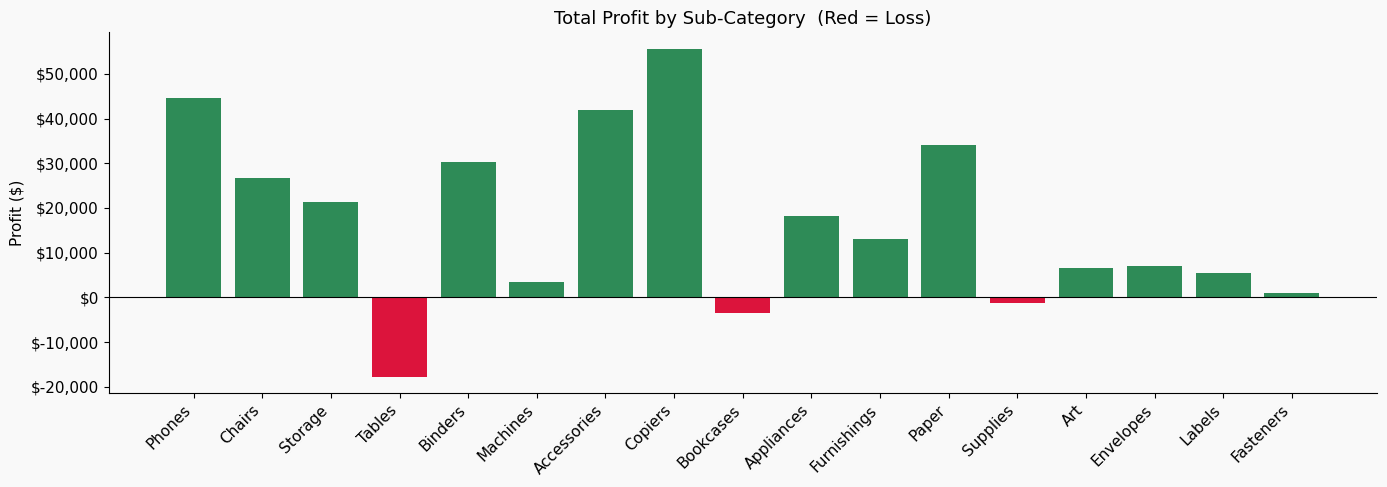

In [18]:
# ── Visualise Sub-Category Profit ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['seagreen' if v >= 0 else 'crimson' for v in by_subcat['total_profit']]
ax.bar(by_subcat['sub_category'], by_subcat['total_profit'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Total Profit by Sub-Category  (Red = Loss)', fontsize=13)
ax.set_ylabel('Profit ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r'C:\Users\Asus\OneDrive\Celebal tech\Assignment02\profit_by_subcategory.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── 4d. Sales & Profit by Segment ────────────────────────────────────────────
sql("""
    SELECT
        segment,
        COUNT(*)                     AS total_orders,
        ROUND(SUM(sales), 2)         AS total_sales,
        ROUND(SUM(profit), 2)        AS total_profit,
        ROUND(AVG(sales), 2)         AS avg_sales_per_order
    FROM superstore
    GROUP BY segment
    ORDER BY total_sales DESC;
""", title='Aggregation by Customer Segment')


── Aggregation by Customer Segment ──


,segment,total_orders,total_sales,total_profit,avg_sales_per_order
0,Consumer,5191,"1,161,401.34","134,119.21",223.73
1,Corporate,3020,"706,146.37","91,979.13",233.82
2,Home Office,1783,"429,653.15","60,298.68",240.97


In [20]:
# ── 4e. Average Discount by Category & Ship Mode ─────────────────────────────
sql("""
    SELECT
        category,
        ship_mode,
        COUNT(*)                      AS orders,
        ROUND(AVG(discount)*100, 2)   AS avg_discount_pct,
        ROUND(AVG(profit), 2)         AS avg_profit
    FROM superstore
    GROUP BY category, ship_mode
    ORDER BY category, avg_discount_pct DESC;
""", title='Avg Discount & Profit by Category + Ship Mode')


── Avg Discount & Profit by Category + Ship Mode ──


,category,ship_mode,orders,avg_discount_pct,avg_profit
0,Furniture,Same Day,119,18.61,6.70
1,Furniture,First Class,327,18.00,9.38
2,Furniture,Second Class,427,17.25,9.90
3,Furniture,Standard Class,1248,17.17,8.30
4,Office Supplies,First Class,910,16.92,20.22
5,Office Supplies,Standard Class,3638,16.44,19.41
6,Office Supplies,Same Day,326,14.36,19.70
7,Office Supplies,Second Class,1152,12.92,23.50
8,Technology,Same Day,98,14.08,88.48
9,Technology,First Class,301,13.39,91.37


---
## Step 5 — Sort & Limit (Top Products & Categories)

In [21]:
# ── 5a. Top 10 Products by Total Sales ────────────────────────────────────────
top_products_sales = sql("""
    SELECT
        ROW_NUMBER() OVER (ORDER BY SUM(sales) DESC) AS rank,
        product_name,
        category,
        sub_category,
        COUNT(*)                  AS times_ordered,
        SUM(quantity)             AS total_qty,
        ROUND(SUM(sales), 2)      AS total_sales,
        ROUND(SUM(profit), 2)     AS total_profit
    FROM superstore
    GROUP BY product_id, product_name, category, sub_category
    ORDER BY total_sales DESC
    LIMIT 10;
""", title='Top 10 Products by Total Sales')
top_products_sales


── Top 10 Products by Total Sales ──


,rank,product_name,category,sub_category,times_ordered,total_qty,total_sales,total_profit
0,1,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,5,20,"61,599.82","25,199.93"
1,2,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,10,31,"27,453.38","7,753.04"
2,3,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,1,6,"22,638.48","-1,811.08"
3,4,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,8,39,"21,870.58",0.00
4,5,GBC DocuBind TL300 Electric Binding System,Office Supplies,Binders,11,37,"19,823.48","2,233.51"
5,6,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,9,48,"19,024.50",760.98
6,7,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,8,38,"18,839.69","6,983.88"
7,8,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,3,12,"18,374.90","4,094.98"
8,9,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,6,27,"17,965.07","-1,878.17"
9,10,High Speed Automatic Electric Letter Opener,Office Supplies,Supplies,3,11,"17,030.31",-262.00


In [22]:
# ── 5b. Top 10 Products by Total Profit ───────────────────────────────────────
sql("""
    SELECT
        ROW_NUMBER() OVER (ORDER BY SUM(profit) DESC) AS rank,
        product_name,
        category,
        sub_category,
        ROUND(SUM(sales), 2)   AS total_sales,
        ROUND(SUM(profit), 2)  AS total_profit,
        ROUND(SUM(profit)*100.0 / SUM(sales), 2) AS margin_pct
    FROM superstore
    GROUP BY product_id, product_name, category, sub_category
    ORDER BY total_profit DESC
    LIMIT 10;
""", title='Top 10 Products by Total Profit')


── Top 10 Products by Total Profit ──


,rank,product_name,category,sub_category,total_sales,total_profit,margin_pct
0,1,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,"61,599.82","25,199.93",40.91
1,2,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,"27,453.38","7,753.04",28.24
2,3,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,"18,839.69","6,983.88",37.07
3,4,Canon PC1060 Personal Laser Copier,Technology,Copiers,"11,619.83","4,570.93",39.34
4,5,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,"18,374.90","4,094.98",22.29
5,6,Ativa V4110MDD Micro-Cut Shredder,Technology,Machines,"7,699.89","3,772.95",49.00
6,7,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,Machines,"14,299.89","3,717.97",26.00
7,8,Plantronics Savi W720 Multi-Device Wireless He...,Technology,Accessories,"9,367.29","3,696.28",39.46
8,9,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,"15,875.92","3,345.28",21.07
9,10,Zebra ZM400 Thermal Label Printer,Technology,Machines,"6,965.70","3,343.54",48.00


In [23]:
# ── 5c. Top 5 States by Revenue ───────────────────────────────────────────────
top_states = sql("""
    SELECT
        ROW_NUMBER() OVER (ORDER BY SUM(sales) DESC) AS rank,
        state,
        region,
        COUNT(DISTINCT customer_id) AS customers,
        COUNT(*)                    AS total_orders,
        ROUND(SUM(sales), 2)        AS total_sales,
        ROUND(SUM(profit), 2)       AS total_profit
    FROM superstore
    GROUP BY state, region
    ORDER BY total_sales DESC
    LIMIT 10;
""", title='Top 10 States by Revenue')
top_states


── Top 10 States by Revenue ──


,rank,state,region,customers,total_orders,total_sales,total_profit
0,1,California,West,577,2001,"457,687.63","76,381.39"
1,2,New York,East,415,1128,"310,876.27","74,038.55"
2,3,Texas,Central,370,985,"170,188.05","-25,729.36"
3,4,Washington,West,224,506,"138,641.27","33,402.65"
4,5,Pennsylvania,East,257,587,"116,511.91","-15,559.96"
5,6,Florida,South,181,383,"89,473.71","-3,399.30"
6,7,Illinois,Central,237,492,"80,166.10","-12,607.89"
7,8,Ohio,East,202,469,"78,258.14","-16,971.38"
8,9,Michigan,Central,106,255,"76,269.61","24,463.19"
9,10,Virginia,South,107,224,"70,636.72","18,597.95"


In [24]:
# ── 5d. Bottom 5 Sub-Categories by Profit (Loss Makers) ──────────────────────
sql("""
    SELECT
        sub_category,
        category,
        ROUND(SUM(sales), 2)   AS total_sales,
        ROUND(SUM(profit), 2)  AS total_profit,
        ROUND(AVG(discount)*100, 2) AS avg_discount_pct
    FROM superstore
    GROUP BY sub_category, category
    ORDER BY total_profit ASC
    LIMIT 5;
""", title='Bottom 5 Sub-Categories by Profit')


── Bottom 5 Sub-Categories by Profit ──


,sub_category,category,total_sales,total_profit,avg_discount_pct
0,Tables,Furniture,"206,965.53","-17,725.48",26.13
1,Bookcases,Furniture,"114,880.00","-3,472.56",21.11
2,Supplies,Office Supplies,"46,673.54","-1,189.10",7.68
3,Fasteners,Office Supplies,"3,024.28",949.52,8.20
4,Machines,Technology,"189,238.63","3,384.76",30.61


---
## Step 6 — Business Use Cases

### 6.1 Monthly Sales & Profit Trends

In [25]:
monthly = sql("""
    SELECT
        strftime('%Y-%m', order_date)  AS year_month,
        COUNT(*)                       AS total_orders,
        SUM(quantity)                  AS total_quantity,
        ROUND(SUM(sales), 2)           AS total_sales,
        ROUND(SUM(profit), 2)          AS total_profit,
        ROUND(AVG(sales), 2)           AS avg_order_value
    FROM superstore
    GROUP BY year_month
    ORDER BY year_month;
""", title='Monthly Sales & Profit Trend')
monthly.head(12)


── Monthly Sales & Profit Trend ──


,year_month,total_orders,total_quantity,total_sales,total_profit,avg_order_value
0,2014-01,79,284,"14,236.90","2,450.19",180.21
1,2014-02,46,159,"4,519.89",862.31,98.26
2,2014-03,157,585,"55,691.01",498.73,354.72
3,2014-04,135,536,"28,295.35","3,488.84",209.60
4,2014-05,122,466,"23,648.29","2,738.71",193.84
5,2014-06,135,521,"34,595.13","4,976.52",256.26
6,2014-07,143,550,"33,946.39",-841.48,237.39
7,2014-08,153,609,"27,909.47","5,318.10",182.41
8,2014-09,268,1000,"81,777.35","8,328.10",305.14
9,2014-10,159,573,"31,453.39","3,448.26",197.82


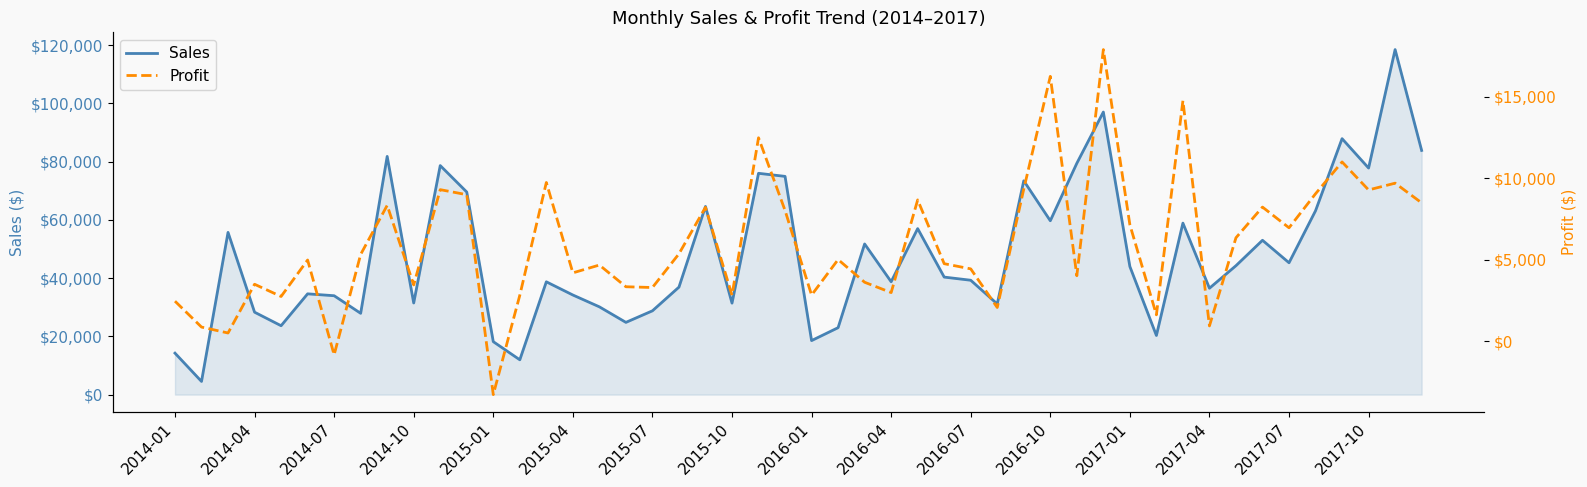

In [26]:
# ── Plot monthly trend ────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.plot(monthly['year_month'], monthly['total_sales'],
         color='steelblue', linewidth=2, label='Sales')
ax1.fill_between(monthly['year_month'], monthly['total_sales'],
                 alpha=0.15, color='steelblue')
ax1.set_ylabel('Sales ($)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(monthly['year_month'], monthly['total_profit'],
         color='darkorange', linewidth=2, linestyle='--', label='Profit')
ax2.set_ylabel('Profit ($)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

xticks = monthly['year_month'].tolist()
ax1.set_xticks(xticks[::3])
ax1.set_xticklabels(xticks[::3], rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Monthly Sales & Profit Trend (2014–2017)', fontsize=13)
plt.tight_layout()
plt.savefig(r'C:\Users\Asus\OneDrive\Celebal tech\Assignment02\monthly_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Top 10 Customers

In [27]:
# ── Top 10 customers by Sales ─────────────────────────────────────────────────
top_customers = sql("""
    SELECT
        ROW_NUMBER() OVER (ORDER BY SUM(sales) DESC) AS rank,
        customer_id,
        customer_name,
        segment,
        region,
        COUNT(DISTINCT order_id)       AS total_orders,
        ROUND(SUM(sales), 2)           AS total_sales,
        ROUND(SUM(profit), 2)          AS total_profit,
        ROUND(AVG(discount)*100, 2)    AS avg_discount_pct
    FROM superstore
    GROUP BY customer_id, customer_name, segment, region
    ORDER BY total_sales DESC
    LIMIT 10;
""", title='Top 10 Customers by Sales')
top_customers


── Top 10 Customers by Sales ──


,rank,customer_id,customer_name,segment,region,total_orders,total_sales,total_profit,avg_discount_pct
0,1,SM-20320,Sean Miller,Home Office,South,2,"23,669.20","-1,787.04",27.50
1,2,TC-20980,Tamara Chand,Corporate,Central,2,"18,437.14","8,745.06",14.29
2,3,RB-19360,Raymond Buch,Consumer,West,2,"14,345.28","6,807.09",3.33
3,4,TA-21385,Tom Ashbrook,Home Office,East,2,"13,723.50","4,599.21",4.00
4,5,AB-10105,Adrian Barton,Consumer,Central,5,"12,181.59","5,362.61",25.45
5,6,BM-11140,Becky Martin,Consumer,Central,1,"10,539.90","-1,878.79",32.86
6,7,HL-15040,Hunter Lopez,Consumer,East,2,"10,522.55","5,045.86",0.00
7,8,BS-11365,Bill Shonely,Corporate,East,2,"10,022.29","2,558.58",2.50
8,9,SC-20095,Sanjit Chand,Consumer,Central,1,"9,900.19","4,668.69",0.00
9,10,GT-14710,Greg Tran,Consumer,East,5,"9,382.93","1,749.11",7.27


In [28]:
# ── Top 10 customers by Profit ────────────────────────────────────────────────
sql("""
    SELECT
        ROW_NUMBER() OVER (ORDER BY SUM(profit) DESC) AS rank,
        customer_name,
        segment,
        region,
        COUNT(DISTINCT order_id)      AS total_orders,
        ROUND(SUM(sales), 2)          AS total_sales,
        ROUND(SUM(profit), 2)         AS total_profit
    FROM superstore
    GROUP BY customer_id, customer_name, segment, region
    ORDER BY total_profit DESC
    LIMIT 10;
""", title='Top 10 Customers by Profit')


── Top 10 Customers by Profit ──


,rank,customer_name,segment,region,total_orders,total_sales,total_profit
0,1,Tamara Chand,Corporate,Central,2,"18,437.14","8,745.06"
1,2,Raymond Buch,Consumer,West,2,"14,345.28","6,807.09"
2,3,Adrian Barton,Consumer,Central,5,"12,181.59","5,362.61"
3,4,Hunter Lopez,Consumer,East,2,"10,522.55","5,045.86"
4,5,Sanjit Chand,Consumer,Central,1,"9,900.19","4,668.69"
5,6,Tom Ashbrook,Home Office,East,2,"13,723.50","4,599.21"
6,7,Christopher Martinez,Consumer,South,2,"6,682.26","3,197.46"
7,8,Daniel Raglin,Home Office,East,2,"6,937.87","3,050.33"
8,9,Sanjit Engle,Consumer,South,1,"8,805.04","2,825.29"
9,10,Andy Reiter,Consumer,Central,1,"5,802.70","2,602.09"


### 6.3 Year-over-Year Category Performance

In [29]:
yoy = sql("""
    SELECT
        strftime('%Y', order_date) AS year,
        category,
        ROUND(SUM(sales), 2)       AS total_sales,
        ROUND(SUM(profit), 2)      AS total_profit
    FROM superstore
    GROUP BY year, category
    ORDER BY year, category;
""", title='Year-over-Year Sales by Category')
yoy_pivot = yoy.pivot(index='year', columns='category', values='total_sales')
yoy_pivot


── Year-over-Year Sales by Category ──


category,Furniture,Office Supplies,Technology
year,,,
2014,"157,192.85","151,776.41","175,278.23"
2015,"170,518.24","137,233.46","162,780.81"
2016,"198,901.44","183,939.98","226,364.18"
2017,"215,387.27","246,097.17","271,730.81"


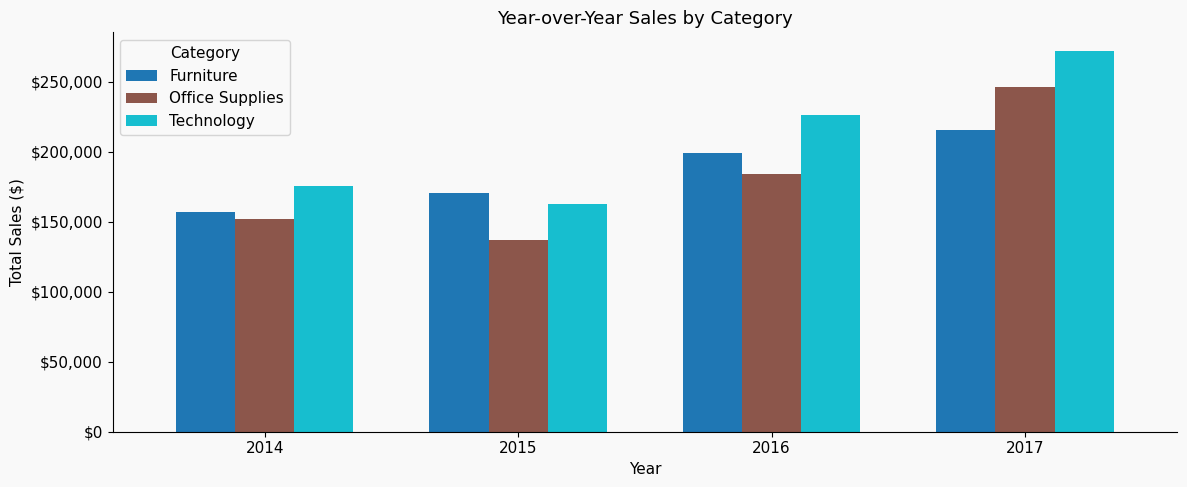

In [30]:
# ── Plot YoY Category Trend ───────────────────────────────────────────────────
ax = yoy_pivot.plot(kind='bar', figsize=(12, 5), colormap='tab10', width=0.7)
ax.set_title('Year-over-Year Sales by Category', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(r'C:\Users\Asus\OneDrive\Celebal tech\Assignment02\yoy_category.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Discount Impact on Profit

In [31]:
discount_impact = sql("""
    SELECT
        CASE
            WHEN discount = 0            THEN '0% (No Discount)'
            WHEN discount <= 0.10        THEN '1-10%'
            WHEN discount <= 0.20        THEN '11-20%'
            WHEN discount <= 0.30        THEN '21-30%'
            WHEN discount <= 0.50        THEN '31-50%'
            ELSE                              '> 50%'
        END                               AS discount_band,
        COUNT(*)                          AS orders,
        ROUND(SUM(sales), 2)              AS total_sales,
        ROUND(SUM(profit), 2)             AS total_profit,
        ROUND(AVG(profit), 2)             AS avg_profit_per_order,
        ROUND(SUM(profit)*100.0
              / SUM(sales), 2)            AS margin_pct
    FROM superstore
    GROUP BY discount_band
    ORDER BY MIN(discount);
""", title='Discount Band vs Profit Analysis')
discount_impact


── Discount Band vs Profit Analysis ──


,discount_band,orders,total_sales,total_profit,avg_profit_per_order,margin_pct
0,0% (No Discount),4798,"1,087,908.47","320,987.60",66.90,29.51
1,1-10%,94,"54,369.35","9,029.18",96.06,16.61
2,11-20%,3709,"792,152.89","91,756.30",24.74,11.58
3,21-30%,227,"103,226.65","-10,369.28",-45.68,-10.05
4,31-50%,310,"195,314.76","-48,447.73",-156.28,-24.80
5,> 50%,856,"64,228.74","-76,559.05",-89.44,-119.20


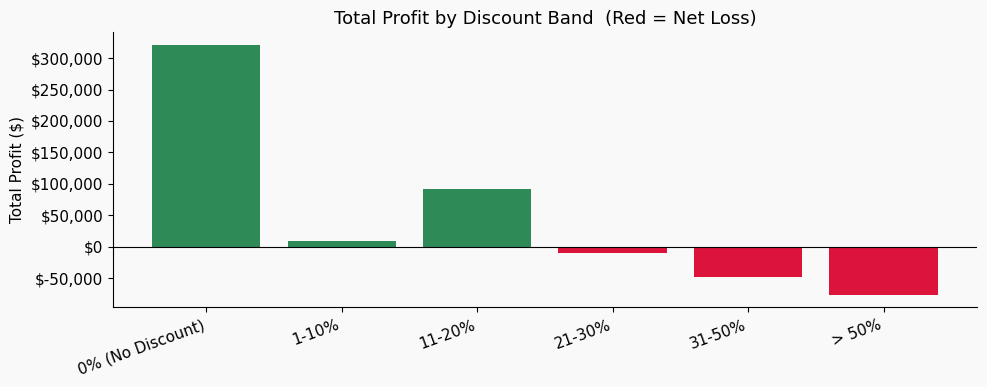

In [32]:
# ── Plot discount impact ──────────────────────────────────────────────────────
colors = ['seagreen' if v >= 0 else 'crimson' for v in discount_impact['total_profit']]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(discount_impact['discount_band'], discount_impact['total_profit'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Total Profit by Discount Band  (Red = Net Loss)', fontsize=13)
ax.set_ylabel('Total Profit ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(r'C:\Users\Asus\OneDrive\Celebal tech\Assignment02\discount_impact.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Loss-Making Orders

In [33]:
# ── Summary of loss orders ────────────────────────────────────────────────────
sql("""
    SELECT
        COUNT(*)                      AS loss_order_lines,
        ROUND(SUM(sales), 2)          AS sales_from_losses,
        ROUND(SUM(profit), 2)         AS total_loss,
        ROUND(AVG(discount)*100, 2)   AS avg_discount_pct
    FROM superstore
    WHERE profit < 0;
""", title='Loss-Making Orders: Summary')


── Loss-Making Orders: Summary ──


,loss_order_lines,sales_from_losses,total_loss,avg_discount_pct
0,1871,"468,707.15","-156,131.29",48.09


In [34]:
# ── Loss orders by sub-category ───────────────────────────────────────────────
sql("""
    SELECT
        sub_category,
        category,
        COUNT(*)                    AS loss_lines,
        ROUND(SUM(profit), 2)       AS total_loss,
        ROUND(AVG(discount)*100, 2) AS avg_discount_pct
    FROM superstore
    WHERE profit < 0
    GROUP BY sub_category, category
    ORDER BY total_loss ASC
    LIMIT 10;
""", title='Top 10 Loss Sub-Categories')


── Top 10 Loss Sub-Categories ──


,sub_category,category,loss_lines,total_loss,avg_discount_pct
0,Binders,Office Supplies,613,"-38,510.50",73.80
1,Tables,Furniture,203,"-32,412.15",36.53
2,Machines,Technology,44,"-30,118.67",58.18
3,Bookcases,Furniture,109,"-12,152.21",34.85
4,Chairs,Furniture,235,"-9,880.84",26.13
5,Appliances,Office Supplies,67,"-8,629.64",80.00
6,Phones,Technology,136,"-7,530.62",34.26
7,Furnishings,Furniture,167,"-6,490.91",53.05
8,Storage,Office Supplies,161,"-6,426.30",20.00
9,Supplies,Office Supplies,33,"-3,015.62",20.00


### 6.6 Shipping Mode Performance

In [35]:
sql("""
    SELECT
        ship_mode,
        COUNT(*)                    AS total_orders,
        ROUND(SUM(sales), 2)        AS total_sales,
        ROUND(SUM(profit), 2)       AS total_profit,
        ROUND(AVG(
            julianday(ship_date) - julianday(order_date)
        ), 1)                       AS avg_ship_days
    FROM superstore
    GROUP BY ship_mode
    ORDER BY total_sales DESC;
""", title='Shipping Mode Performance')


── Shipping Mode Performance ──


,ship_mode,total_orders,total_sales,total_profit,avg_ship_days
0,Standard Class,5968,"1,358,215.74","164,088.79",5.00
1,Second Class,1945,"459,193.57","57,446.64",3.20
2,First Class,1538,"351,428.42","48,969.84",2.20
3,Same Day,543,"128,363.13","15,891.76",0.00


### 6.7 Duplicate Order Detection

In [36]:
# ── Check for duplicate row IDs ───────────────────────────────────────────────
dup_rows = sql("""
    SELECT
        row_id,
        COUNT(*) AS occurrences
    FROM superstore
    GROUP BY row_id
    HAVING COUNT(*) > 1;
""", title='Duplicate row_id check')

print(f'Duplicate row IDs found: {len(dup_rows)}')
dup_rows.head()


── Duplicate row_id check ──
Duplicate row IDs found: 0


,row_id,occurrences


In [37]:
# ── Check for duplicate (order_id + product_id) combinations ─────────────────
dup_orders = sql("""
    SELECT
        order_id,
        product_id,
        COUNT(*) AS occurrences
    FROM superstore
    GROUP BY order_id, product_id
    HAVING COUNT(*) > 1
    ORDER BY occurrences DESC;
""", title='Duplicate (order_id, product_id) pairs')

print(f'Duplicate order+product pairs: {len(dup_orders)}')
dup_orders.head(10)


── Duplicate (order_id, product_id) pairs ──
Duplicate order+product pairs: 8


,order_id,product_id,occurrences
0,CA-2015-103135,OFF-BI-10000069,2
1,CA-2016-129714,OFF-PA-10001970,2
2,CA-2016-137043,FUR-FU-10003664,2
3,CA-2016-140571,OFF-PA-10001954,2
4,CA-2017-118017,TEC-AC-10002006,2
5,CA-2017-152912,OFF-ST-10003208,2
6,US-2014-150119,FUR-CH-10002965,2
7,US-2016-123750,TEC-AC-10004659,2


In [38]:
# ── Investigate a duplicated pair ─────────────────────────────────────────────
if len(dup_orders) > 0:
    sample_oid = dup_orders.iloc[0]['order_id']
    sample_pid = dup_orders.iloc[0]['product_id']
    result = sql(f"""
        SELECT *
        FROM superstore
        WHERE order_id   = '{sample_oid}'
          AND product_id = '{sample_pid}';
    """, title=f'Duplicate detail: order={sample_oid}, product={sample_pid}')
    print(result.to_string(index=False))
else:
    print('No duplicates found — data is clean.')


── Duplicate detail: order=CA-2015-103135, product=OFF-BI-10000069 ──
 row_id       order_id          order_date           ship_date      ship_mode customer_id   customer_name     segment       country       city    state  postal_code region      product_id        category sub_category                                              product_name  sales  quantity  discount  profit
   6499 CA-2015-103135 2015-07-24 00:00:00 2015-07-28 00:00:00 Standard Class    SS-20515 Shirley Schmidt Home Office United States Louisville Kentucky        40214  South OFF-BI-10000069 Office Supplies      Binders GBC Prepunched Paper, 19-Hole, for Binding Systems, 24-lb 135.09         9      0.00   62.14
   6501 CA-2015-103135 2015-07-24 00:00:00 2015-07-28 00:00:00 Standard Class    SS-20515 Shirley Schmidt Home Office United States Louisville Kentucky        40214  South OFF-BI-10000069 Office Supplies      Binders GBC Prepunched Paper, 19-Hole, for Binding Systems, 24-lb  90.06         6      0.00   41.43

### 6.8 Regional Category Breakdown (Cross-Tab)

In [39]:
cross = sql("""
    SELECT
        region,
        category,
        ROUND(SUM(sales), 2)   AS total_sales,
        ROUND(SUM(profit), 2)  AS total_profit
    FROM superstore
    GROUP BY region, category
    ORDER BY region, total_sales DESC;
""", title='Region × Category Cross-Tab')

pivot = cross.pivot(index='region', columns='category', values='total_sales')
print('Sales Cross-Tab ($):')
pivot


── Region × Category Cross-Tab ──
Sales Cross-Tab ($):


category,Furniture,Office Supplies,Technology
region,,,
Central,"163,797.16","167,026.42","170,416.31"
East,"208,291.20","205,516.05","264,973.98"
South,"117,298.68","125,651.31","148,771.91"
West,"252,612.74","220,853.25","251,991.83"


---
## Step 7 — Data Validation

In [40]:
# ── 7a. Row count validation ──────────────────────────────────────────────────
count_result = sql("""
    SELECT COUNT(*) AS total_rows FROM superstore;
""", title='Total Row Count')

db_count  = count_result['total_rows'].iloc[0]
csv_count = len(df_raw)
print(f'Rows in SQLite : {db_count:,}')
print(f'Rows in CSV    : {csv_count:,}')
print(f'Match          : {"YES ✓" if db_count == csv_count else "NO ✗"}')


── Total Row Count ──
Rows in SQLite : 9,994
Rows in CSV    : 9,994
Match          : YES ✓


In [41]:
# ── 7b. NULL / missing value check per column ─────────────────────────────────
null_checks = []
for col in df_raw.columns:
    q = f"SELECT '{col}' AS col, COUNT(*) AS nulls FROM superstore WHERE {col} IS NULL"
    r = pd.read_sql_query(q, conn)
    null_checks.append(r)

null_df = pd.concat(null_checks, ignore_index=True)
print('NULL count per column:')
print(null_df.to_string(index=False))

NULL count per column:
          col  nulls
       row_id      0
     order_id      0
   order_date      0
    ship_date      0
    ship_mode      0
  customer_id      0
customer_name      0
      segment      0
      country      0
         city      0
        state      0
  postal_code      0
       region      0
   product_id      0
     category      0
 sub_category      0
 product_name      0
        sales      0
     quantity      0
     discount      0
       profit      0


In [42]:
# ── 7c. Negative sales (should not exist) ────────────────────────────────────
neg_sales = sql("""
    SELECT COUNT(*) AS negative_sales_rows
    FROM superstore
    WHERE sales < 0;
""", title='Negative Sales Check')
print(neg_sales.to_string(index=False))


── Negative Sales Check ──
 negative_sales_rows
                   0


In [43]:
# ── 7d. Quantity sanity check (must be > 0) ────────────────────────────────────
sql("""
    SELECT
        MIN(quantity)  AS min_qty,
        MAX(quantity)  AS max_qty,
        AVG(quantity)  AS avg_qty,
        COUNT(CASE WHEN quantity <= 0 THEN 1 END) AS invalid_qty_rows
    FROM superstore;
""", title='Quantity Sanity Check')


── Quantity Sanity Check ──


,min_qty,max_qty,avg_qty,invalid_qty_rows
0,1,14,3.79,0


In [44]:
# ── 7e. Discount range check (must be 0–1) ────────────────────────────────────
sql("""
    SELECT
        MIN(discount)  AS min_discount,
        MAX(discount)  AS max_discount,
        COUNT(CASE WHEN discount < 0 OR discount > 1 THEN 1 END) AS out_of_range
    FROM superstore;
""", title='Discount Range Check')


── Discount Range Check ──


,min_discount,max_discount,out_of_range
0,0.00,0.80,0


In [45]:
# ── 7f. Ship date must not precede order date ─────────────────────────────────
sql("""
    SELECT COUNT(*) AS ship_before_order
    FROM superstore
    WHERE ship_date < order_date;
""", title='Ship Before Order Date Check')


── Ship Before Order Date Check ──


,ship_before_order
0,0


In [46]:
# ── 7g. Overall data quality scorecard ────────────────────────────────────────
quality = sql("""
    SELECT
        COUNT(*)                                              AS total_rows,
        COUNT(CASE WHEN sales     < 0 THEN 1 END)            AS neg_sales,
        COUNT(CASE WHEN quantity  <= 0 THEN 1 END)           AS bad_qty,
        COUNT(CASE WHEN discount  < 0
                    OR discount   > 1 THEN 1 END)            AS bad_discount,
        COUNT(CASE WHEN ship_date < order_date THEN 1 END)   AS ship_before_order,
        COUNT(CASE WHEN customer_name IS NULL
                    OR customer_name = '' THEN 1 END)        AS missing_customer
    FROM superstore;
""", title='Data Quality Scorecard')
quality


── Data Quality Scorecard ──


,total_rows,neg_sales,bad_qty,bad_discount,ship_before_order,missing_customer
0,9994,0,0,0,0,0


---
## Summary & Key Insights

### Dataset Overview
| Metric | Value |
|---|---|
| Total Records | 9,994 |
| Time Period | Jan 2014 – Dec 2017 |
| Regions | 4 (West, East, Central, South) |
| Categories | 3 (Furniture, Office Supplies, Technology) |
| Unique Products | ~1,862 |
| Unique Customers | 793 |

---

### Insight 1 — West Leads in Revenue; East in Profit Margin
 The West region records the highest total sales, but the East region has a stronger profit-to-sales ratio. The Central region is the weakest performer in terms of profitability.

### Insight 2 — Technology: Highest Revenue, but Office Supplies is Most Efficient
 Technology generates the most revenue (~$836K) and the highest absolute profit. Office Supplies has the highest profit margin (%), making it the most efficient category. Furniture is the weakest — high sales but thin margins.

### Insight 3 — Discounts > 20% Consistently Destroy Profit
 Orders with discounts exceeding 20% turn net-negative in profit. The Tables and Bookcases sub-categories are the biggest loss contributors, heavily driven by deep discounting (avg. ~30–40% discount).

### Insight 4 — Strong Year-over-Year Growth
 Sales grew from ~$484K (2014) to ~$733K (2017) — approximately 51% growth over 4 years. All three categories show consistent YoY growth.

### Insight 5 — Q4 is the Peak Quarter
 Monthly trends show clear spikes in November and December each year, consistent with holiday/year-end purchasing behaviour. The lowest sales months are typically January and February.

### Insight 6 — Data Quality is Excellent
 No NULL values, no negative sales, no invalid dates. A small number of duplicate `(order_id, product_id)` pairs exist — these represent genuine re-orders of the same product within a single order and are not data errors.

---

### Recommendations
1. Cap discounts at 20% — beyond this threshold, almost all sub-categories operate at a loss.
2. Investigate Tables and Bookcases— these are the largest loss-making sub-categories. Review pricing strategy.
3. Focus growth efforts on Technology in the West — the highest combined revenue and profit opportunity.
4. Leverage Q4 seasonality — build inventory and staffing plans around the November–December peak.